## PRAKTIKUM
### Nama: Natasya M. Tambunan
### NIM: 42324009
### Prodi: D-III Teknologi Informasi

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


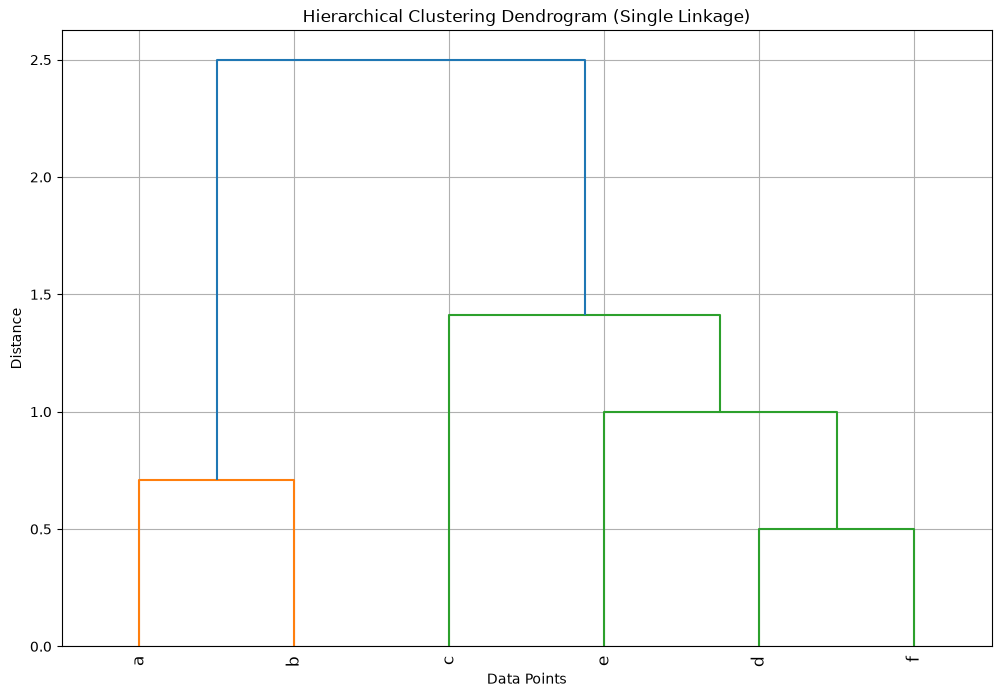

In [ ]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# 1. Dataset sederhana
data = np.array([
    [1.0, 1.0],   # a
    [1.5, 1.5],   # b
    [5.0, 5.0],   # c
    [3.0, 4.0],   # d
    [4.0, 4.0],   # e
    [3.0, 3.5]    # f
])

# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(
    squareform(distance_matrix),
    columns=['a', 'b', 'c', 'd', 'e', 'f'],
    index=['a', 'b', 'c', 'd', 'e', 'f']
)

# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')

# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")

dendrogram(
    linked,
    labels=['a', 'b', 'c', 'd', 'e', 'f'],
    leaf_rotation=90
)

plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

#### Pada tahap ini dilakukan implementasi metode Hierarchical Clustering menggunakan dataset sederhana untuk memahami konsep dasar pengelompokan data. Pertama, dilakukan import beberapa library yang dibutuhkan, yaitu numpy untuk pengolahan data numerik, pandas untuk pengolahan data dalam bentuk tabel, scipy.cluster.hierarchy untuk proses clustering dan visualisasi dendrogram, serta matplotlib untuk menampilkan grafik. Library pdist dan squareform digunakan untuk menghitung dan menampilkan matriks jarak antar data.
#### Selanjutnya, dibuat dataset sederhana menggunakan numpy array yang terdiri dari enam titik data (a hingga f), di mana setiap titik memiliki dua atribut. Dataset ini digunakan sebagai contoh awal untuk mempermudah pemahaman terhadap proses perhitungan jarak dan pembentukan cluster.
#### Setelah dataset dibuat, dilakukan perhitungan jarak antar data menggunakan metode Euclidean Distance melalui fungsi pdist(). Hasil perhitungan jarak ini kemudian diubah menjadi bentuk matriks menggunakan squareform() dan disimpan dalam bentuk DataFrame menggunakan pandas. Matriks jarak ini menunjukkan seberapa dekat atau jauh hubungan antar data, yang menjadi dasar dalam proses clustering.
#### Selanjutnya, matriks jarak ditampilkan menggunakan perintah print() untuk memberikan gambaran numerik hubungan antar data. Nilai yang lebih kecil menunjukkan bahwa dua data memiliki kemiripan yang lebih tinggi dibandingkan dengan nilai yang lebih besar.
#### Tahap berikutnya adalah melakukan Hierarchical Clustering menggunakan metode Single Linkage dengan fungsi linkage(). Metode ini bekerja dengan cara menggabungkan dua cluster yang memiliki jarak terdekat berdasarkan pasangan titik terdekat antar cluster. Proses ini dilakukan secara bertahap hingga seluruh data tergabung dalam satu hierarki cluster.
#### Hasil dari proses clustering kemudian divisualisasikan dalam bentuk dendrogram menggunakan fungsi dendrogram(). Dendrogram merupakan diagram berbentuk pohon yang menunjukkan proses penggabungan cluster dari tahap awal hingga akhir. Pada grafik ini, sumbu X menunjukkan data points (a hingga f), sedangkan sumbu Y menunjukkan jarak antar cluster saat penggabungan terjadi.
#### Selain itu, dilakukan pengaturan tampilan grafik seperti ukuran figure, judul, label sumbu, dan grid untuk memperjelas visualisasi. Fungsi plt.show() digunakan untuk menampilkan dendrogram secara keseluruhan.
#### Visualisasi dendrogram ini sangat penting karena dapat digunakan untuk menentukan jumlah cluster yang optimal dengan cara memotong pohon pada tingkat jarak tertentu. Dengan demikian, pengguna dapat melihat bagaimana data dikelompokkan secara hierarkis dan memahami struktur hubungan antar data secara lebih mendalam.

In [3]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### Pertama, dilakukan import library pandas yang digunakan untuk mengolah data dalam bentuk tabel (DataFrame). Dataset Mall_Customers.csv kemudian dibaca menggunakan fungsi read_csv() dan disimpan dalam variabel df. Setelah itu, digunakan fungsi df.head() untuk menampilkan lima baris pertama dari dataset. Langkah ini bertujuan untuk memastikan bahwa data telah berhasil dimuat dengan benar serta untuk memahami struktur data, seperti nama kolom dan isi awal dataset.

In [4]:
x = df.iloc[:, [3, 4]].values

#### Pada tahap ini dilakukan pemilihan fitur yang relevan untuk proses clustering, yaitu Annual Income dan Spending Score. Pemilihan dilakukan menggunakan df.iloc[:, [3, 4]].values, yang berarti mengambil kolom ke-3 dan ke-4 dari dataset berdasarkan indeks. Hasilnya disimpan dalam variabel x dalam bentuk array. Pemilihan kedua fitur ini bertujuan untuk menyederhanakan analisis serta fokus pada karakteristik utama yang memengaruhi pola pengeluaran pelanggan.

In [5]:
from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()

scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

#### Selanjutnya dilakukan proses normalisasi data menggunakan StandardScaler dari library sklearn.preprocessing. Proses ini bertujuan untuk mengubah skala data sehingga memiliki distribusi dengan rata-rata 0 dan standar deviasi 1. Hal ini penting karena algoritma clustering, termasuk hierarchical clustering, sensitif terhadap perbedaan skala antar fitur. Data yang telah dinormalisasi disimpan dalam variabel scaled_data menggunakan fungsi fit_transform(). Selain itu, digunakan scaled_data.shape untuk memastikan ukuran data setelah proses scaling, yaitu jumlah baris dan kolom.

In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(scaled_data, method="complete", metric="euclidean")

#### Setelah data dinormalisasi, dilakukan proses clustering menggunakan metode Hierarchical Clustering dengan teknik complete linkage. Proses ini dilakukan menggunakan fungsi linkage() dengan parameter method="complete" dan metric="euclidean". Metode complete linkage bekerja dengan mengukur jarak maksimum antara anggota dari dua cluster yang berbeda. Dengan pendekatan ini, cluster yang terbentuk cenderung lebih kompak dan memiliki jarak antar anggota yang relatif lebih seragam.

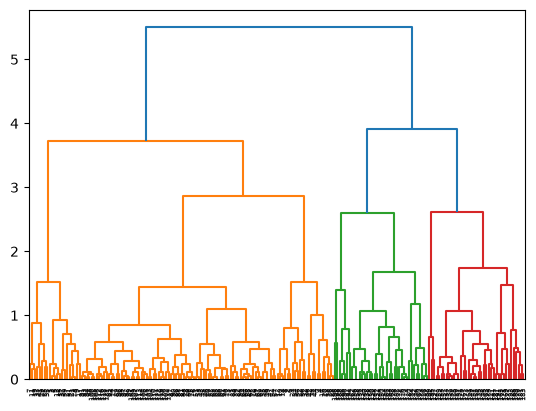

In [7]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

#### Tahap terakhir adalah visualisasi hasil clustering menggunakan dendrogram. Dendrogram dibuat menggunakan fungsi dendrogram(clustering) dan ditampilkan menggunakan plt.show(). Dendrogram merupakan diagram berbentuk pohon yang menunjukkan proses penggabungan cluster secara bertahap. Pada dendrogram, sumbu vertikal menunjukkan jarak antar cluster, sedangkan sumbu horizontal menunjukkan data atau objek yang dikelompokkan.
#### Visualisasi ini sangat penting karena dapat digunakan untuk menentukan jumlah cluster yang optimal dengan cara melihat jarak pemotongan (cut-off) pada dendrogram. Dengan memotong dendrogram pada ketinggian tertentu, dapat diperoleh jumlah cluster yang paling sesuai berdasarkan struktur data yang terbentuk.

# TUGAS

#### Pada percobaan pertama, kami menggunakan dataset sederhana yang terdiri dari beberapa titik data untuk memahami perbedaan hasil dendrogram pada metode single linkage, complete linkage, dan average linkage dalam Hierarchical Clustering. Ketiga metode ini memiliki pendekatan yang berbeda dalam menghitung jarak antar cluster, sehingga menghasilkan struktur dendrogram yang berbeda.
### 1. Single Linkage
#### Pada metode single linkage, jarak antar cluster ditentukan berdasarkan jarak terdekat (minimum distance) antara dua titik dari cluster yang berbeda. Berdasarkan hasil dendrogram yang diperoleh dari dataset sederhana, terlihat bahwa proses penggabungan cluster terjadi secara bertahap dengan menghubungkan titik-titik yang paling dekat terlebih dahulu.
#### Akibatnya, terbentuk pola seperti rantai (chaining effect), di mana data yang sebenarnya cukup jauh tetap dapat tergabung dalam satu cluster karena adanya titik perantara yang lebih dekat. Hal ini menyebabkan struktur cluster menjadi memanjang dan kurang kompak. Oleh karena itu, metode ini kurang efektif dalam memisahkan kelompok data secara jelas.

### 2. Complete Linkage
#### Pada metode complete linkage, jarak antar cluster ditentukan berdasarkan jarak terjauh (maximum distance) antara dua titik dari cluster yang berbeda. Berdasarkan dendrogram yang dihasilkan, terlihat bahwa cluster yang terbentuk lebih rapat dan memiliki batas yang lebih jelas dibandingkan dengan single linkage.
#### Proses penggabungan cluster pada metode ini cenderung lebih hati-hati karena mempertimbangkan jarak terjauh, sehingga cluster yang dihasilkan lebih homogen dan tidak mudah terpengaruh oleh data yang menyebar jauh. Dengan demikian, metode complete linkage menghasilkan struktur cluster yang lebih stabil dan terpisah dengan baik.

### 3. Average Linkage
#### Metode average linkage menentukan jarak antar cluster berdasarkan rata-rata jarak antar seluruh pasangan titik dari dua cluster yang berbeda. Berdasarkan hasil dendrogram, metode ini menghasilkan struktur cluster yang lebih seimbang dibandingkan dua metode sebelumnya.
#### Cluster yang terbentuk tidak terlalu memanjang seperti pada single linkage dan juga tidak terlalu ketat seperti pada complete linkage. Oleh karena itu, average linkage dapat dianggap sebagai metode kompromi yang mampu memberikan hasil clustering yang cukup baik dan stabil.

### Kesimpulan
#### Dari hasil percobaan pada dataset sederhana, kami menyimpulkan bahwa metode complete linkage memberikan hasil clustering yang paling baik dalam hal kejelasan pemisahan antar cluster. Metode average linkage juga memberikan hasil yang cukup baik karena menghasilkan cluster yang lebih seimbang. Sementara itu, metode single linkage kurang optimal karena menghasilkan cluster yang memanjang dan kurang merepresentasikan struktur data secara akurat.